# MI-FACE

In this tutorial, we introduce the basic model inversion algorithm MI-FACE, which reconstruct the class representation within the training dataset.

In [1]:
!apt install -y libboost-all-dev

!pip install -U pip
!pip install "pybind11[global]"
!pip install aijack

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  javascript-common libboost-atomic-dev libboost-atomic1.74-dev
  libboost-atomic1.74.0 libboost-chrono-dev libboost-chrono1.74-dev
  libboost-chrono1.74.0 libboost-container-dev libboost-container1.74-dev
  libboost-container1.74.0 libboost-context-dev libboost-context1.74-dev
  libboost-context1.74.0 libboost-coroutine-dev libboost-coroutine1.74-dev
  libboost-coroutine1.74.0 libboost-date-time-dev libboost-date-time1.74-dev
  libboost-date-time1.74.0 libboost-exception-dev libboost-exception1.74-dev
  libboost-fiber-dev libboost-fiber1.74-dev libboost-fiber1.74.0
  libboost-filesystem-dev libboost-filesystem1.74-dev
  libboost-filesystem1.74.0 libboost-graph-dev libboost-graph-parallel-dev
  libboost-graph-parallel1.74-dev libboost-graph-parallel1.74.0
  libboost-graph1.74-dev libboost-graph1.74.0 libboost-iostreams-dev
  libboost-iost

In [2]:
!apt-get update -qq
!apt-get install -y --fix-missing \
  libboost-filesystem-dev libboost-system-dev libboost-thread-dev \
  libboost-serialization-dev libboost-regex-dev libboost-program-options-dev \
  libboost-date-time-dev libboost-iostreams-dev libboost-log-dev \
  libboost-random-dev libboost-math-dev libboost-chrono-dev

!pip install aijack

#If !pip install aijack still fails, run this to see the full error:
#!pip install aijack -v 2>&1 | tail -60

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libboost-atomic1.74-dev libboost-atomic1.74.0 libboost-chrono1.74-dev
  libboost-chrono1.74.0 libboost-date-time1.74-dev libboost-date-time1.74.0
  libboost-filesystem1.74-dev libboost-filesystem1.74.0
  libboost-iostreams1.74-dev libboost-iostreams1.74.0 libboost-log1.74-dev
  libboost-log1.74.0 libboost-math1.74-dev libboost-math1.74.0
  libboost-program-options1.74-dev libboost-program-options1.74.0
  libboost-random1.74-dev libboost-random1.74.0 libboost-regex1.74-dev
  libboost-regex1.74.0 libboost-serialization1.74-dev
  libboost-serialization1.74.0 libboost-system1.74-dev libboost-system1.74.0
  libboost-thread1.74-dev libboost-thread1.74.0
The

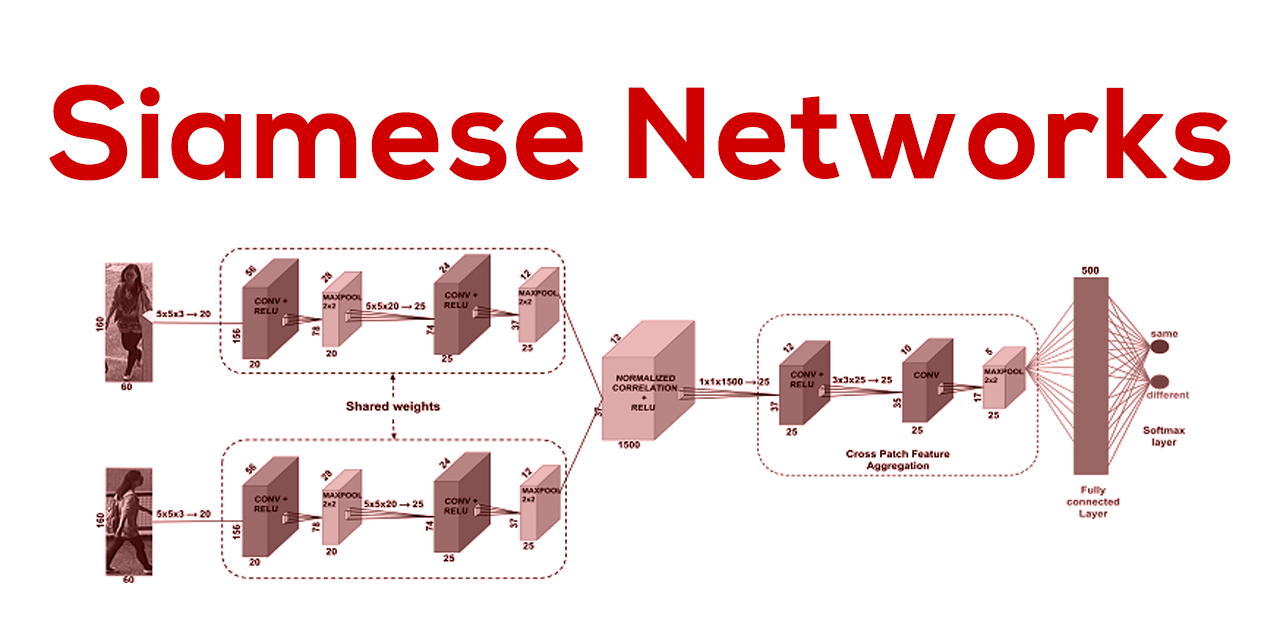

In [3]:
!git clone https://github.com/harveyslash/Facial-Similarity-with-Siamese-Networks-in-Pytorch.git
!mkdir data
!mv Facial-Similarity-with-Siamese-Networks-in-Pytorch/data/faces/testing/* data/
!mv Facial-Similarity-with-Siamese-Networks-in-Pytorch/data/faces/training/* data/

Cloning into 'Facial-Similarity-with-Siamese-Networks-in-Pytorch'...
remote: Enumerating objects: 550, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 550 (delta 6), reused 18 (delta 6), pack-reused 532 (from 1)
Receiving objects: 100% (550/550), 6.32 MiB | 22.41 MiB/s, done.
Resolving deltas: 100% (27/27), done.


In [12]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset
from matplotlib import pyplot as plt
import glob
from sklearn.metrics import accuracy_score
from aijack.attack import MI_FACE
from aijack.defense import GeneralMomentAccountant, DPSGDManager
from aijack.utils import NumpyDataset

BASE = "data/"

In [19]:
# Define a neural network class called Net
# This class inherits from the nn.Module class in PyTorch
class Net(nn.Module):
    # Constructor method for the Net class
    def __init__(self):
        # Call the constructor of the parent class (nn.Module)
        super(Net, self).__init__()

        # Define a Flatten layer to flatten the input image tensor
        self.fla = nn.Flatten()

        # Define a fully connected (linear) layer with input size 112 * 92 and output size 40
        self.fc = nn.Linear(112 * 92, 40)

    # Forward method that defines the forward pass of the neural network
    def forward(self, x):
        # Flatten the input image tensor
        x = self.fla(x)

        # Pass the flattened tensor through the fully connected layer
        x = self.fc(x)

        # Apply softmax activation function to the output tensor along dimension 1
        # Softmax function normalizes the output values to a probability distribution
        # along the specified dimension, which in this case, is the class dimension
        x = F.softmax(x, dim=1)

        # Return the output tensor
        return x


## Setup

In [20]:
# Initialize empty lists to store images and corresponding labels
imgs = []  # List to store images
labels = []  # List to store labels

# Loop through each subject (1 to 40)
for i in range(1, 41):
    # Loop through each image of the subject (1 to 10)
    for j in range(1, 11):
        # Read the image using OpenCV (cv2) from the specified path
        img = cv2.imread(BASE + f"s{i}/{j}.pgm", 0)  # Read grayscale image
        imgs.append(img)  # Append the image to the list
        labels.append(i - 1)  # Append the label (subject number) to the list

# Convert the lists of images and labels into numpy arrays
X = np.stack(imgs)  # Convert list of images into a numpy array
y = np.array(labels)  # Convert list of labels into a numpy array

# Define a sequence of transformations to be applied to the images
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        transforms.Normalize((0.5,), (0.5,)),  # Normalize the image tensors
    ]
)

# Create a custom dataset using the numpy arrays of images and labels
# Apply the defined transformations to each image
trainset = NumpyDataset(X, y, transform=transform)

# Create a data loader to load data in batches during training
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True, num_workers=2
)

# Instantiate the neural network model (Net class)
net = Net()

# Define the loss function (criterion) as Cross Entropy Loss
criterion = nn.CrossEntropyLoss()

# Define the optimizer as Stochastic Gradient Descent (SGD) with momentum
optimizer = optim.SGD(net.parameters(), lr=0.005, momentum=0.9)


## Training the target model

In [21]:
# Loop over the dataset multiple times (10 epochs)
for epoch in range(10):
    running_loss = 0  # Initialize running loss for the current epoch
    data_size = 0  # Initialize the total size of the dataset processed in the current epoch

    # Iterate over the data loader (trainloader) to process batches of data
    for i, data in enumerate(trainloader, 0):
        # Get the inputs and labels from the data loader
        inputs, labels = data

        # Zero the gradients to clear any previous gradients
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs through the network
        outputs = net(inputs)

        # Compute the loss using the specified criterion (Cross Entropy Loss)
        loss = criterion(outputs, labels.to(torch.int64))

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # Perform optimization step: update model parameters
        optimizer.step()

        # Update running loss and data size
        running_loss += loss.item()
        data_size += inputs.shape[0]  # inputs.shape[0] gives the batch size

    # Print the average loss for the current epoch
    print(f"epoch {epoch}: loss is {running_loss/data_size}")

# Initialize empty lists to store predictions and labels for the training set
in_preds = []
in_label = []

# Disable gradient calculation to speed up inference
with torch.no_grad():
    # Iterate over the data loader (trainloader) to perform inference on batches of data
    for data in trainloader:
        inputs, labels = data  # Get the inputs and labels
        outputs = net(inputs)  # Perform forward pass to get predicted outputs
        in_preds.append(outputs)  # Append predicted outputs to the list
        in_label.append(labels)  # Append true labels to the list

    # Concatenate the list of predicted outputs and true labels along the batch dimension
    # This will give a single tensor for predicted outputs and true labels respectively
    in_preds = torch.cat(in_preds)
    in_label = torch.cat(in_label)

# Compute the accuracy score for the training set
# Accuracy score is calculated by comparing predicted labels with true labels
print(
    "Test Accuracy is: ",
    accuracy_score(np.array(torch.argmax(in_preds, axis=1)), np.array(in_label)),
)


epoch 0: loss is 0.9162753099203109
epoch 1: loss is 0.8642228400707245
epoch 2: loss is 0.811486759185791
epoch 3: loss is 0.7726247930526733
epoch 4: loss is 0.74710424721241
epoch 5: loss is 0.73306611597538
epoch 6: loss is 0.7288129925727844
epoch 7: loss is 0.7276901823282241
epoch 8: loss is 0.7269653040170669
epoch 9: loss is 0.7244872272014617
Test Accuracy is:  0.85


## Attack

Model Inversion (MI) attacks are a class of privacy attacks that aim to reconstruct sensitive input data, such as images, from the output of a machine learning model. MI Face is a specific type of model inversion attack targeted towards facial recognition systems. In MI Face, attackers attempt to reconstruct facial images from the output of a facial recognition model to infer whether a particular individual's face was present in the training dataset.

Code Flow:

MI_FACE Initialization: The MI_FACE class is initialized with the neural network model (net), input shape, target label, regularization parameter, and other attack parameters.

Attack Execution: The attack is executed by calling the attack() method of the MI_FACE object. This method performs the model inversion attack and returns the reconstructed image (x_result_1) along with optional logs.

Visualization: The reconstructed image is visualized alongside the original image for comparison. A subplot with two axes is created to display both images. The original image is loaded from the dataset, while the reconstructed image (x_result_1) is obtained from the model inversion attack results. Both images are displayed using matplotlib.pyplot.imshow(), and axes properties are set for visualization. Finally, the figure is shown.

This code flow demonstrates how the MI Face attack is implemented and visualized, providing insights into the process of reconstructing facial images from a facial recognition model's outputs.

In [25]:
# Define the shape of the input image tensor as (batch_size, channels, height, width)
# For grayscale images with dimensions 112x92, the shape is (1, 1, 112, 92)
input_shape = (1, 1, 112, 92)

# Define the target label for the model inversion attack
# In MI_FACE attack, the attacker aims to reconstruct an image that is classified as the target label
target_label = 11

# Define the regularization parameter lambda for the model inversion attack
# Lambda controls the trade-off between data fidelity and regularization
lam = 0.001

# Define the number of iterations for the optimization process in the model inversion attack
num_itr = 100

# Initialize an instance of the MI_FACE attack
# Parameters:
#   - net: The neural network model to be attacked
#   - input_shape: Shape of the input image tensor
#   - target_label: Target label for the attack
#   - num_itr: Number of iterations for the optimization process
#   - lam: Regularization parameter lambda
#   - log_interval: Interval for logging intermediate results (set to 0 for no logging)
mi = MI_FACE(
    net,
    input_shape,
    target_label=target_label,
    num_itr=num_itr,
    lam=lam,
    log_interval=0,
)

# Perform the MI_FACE attack to reconstruct an image that is classified as the target label
# Returns the reconstructed image (x_result_1) and the log containing intermediate results
x_result_1, log = mi.attack()


first 10 values:
[0.975017249584198, 0.9750167727470398, 0.9750163555145264, 0.9750159382820129, 0.9750155210494995, 0.9750151038169861, 0.9750146865844727, 0.9750142693519592, 0.975013792514801, 0.9750133752822876]

last 10 values:
[0.9749788641929626, 0.9749784469604492, 0.9749780297279358, 0.9749775528907776, 0.9749771356582642, 0.9749767184257507, 0.9749763011932373, 0.9749758839607239, 0.9749754667282104, 0.9749749898910522]


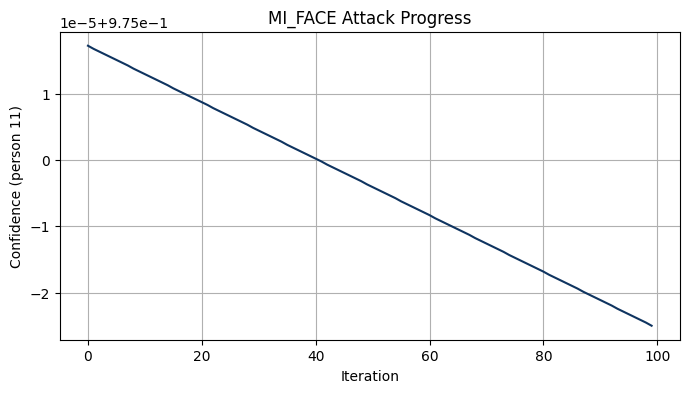

In [31]:
# log

import matplotlib.pyplot as plt

# print first 10 values
print("first 10 values:")
print(log[:10])

# print last 10 values
print("\nlast 10 values:")
print(log[-10:])

# log
plt.figure(figsize=(8, 4))
plt.plot(log, color='#0f3460')
plt.xlabel("Iteration")
plt.ylabel("Confidence (person 11)")
plt.title("MI_FACE Attack Progress")
plt.grid(True)
plt.show()

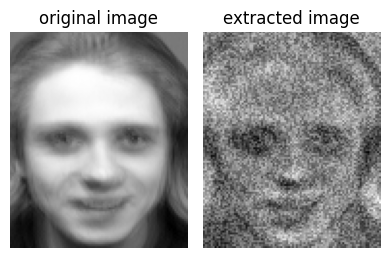

In [30]:
# Create a figure with 1 row and 2 columns of subplots, with a specified figure size
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4, 3))

# Plot the original image reconstructed from a set of images of the same subject
# by taking the mean of all the images and displaying it in grayscale
axes[0].imshow(
    np.mean([cv2.imread(p, 0) for p in glob.glob(BASE + "s12/*.pgm")], axis=0),
    cmap="gray",
)

# Turn off axis for the first subplot and set its title
axes[0].axis("off")
axes[0].set_title("original image")

# Plot the extracted image obtained from the model inversion attack
# Convert the tensor to a numpy array and display it in grayscale
axes[1].imshow(x_result_1[0][0].detach().numpy(), cmap="gray")

# Turn off axis for the second subplot and set its title
axes[1].axis("off")
axes[1].set_title("extracted image")

# Adjust the layout of subplots to prevent overlap
fig.tight_layout()

# Display the figure
fig.show()
